# Z4 wall-width → lattice-parameter calculator (PRS fat-wall runs)

Chooses the box length `lSide` (and reports the achievable `tMax`) so that, **under the
PRS fat-wall scheme**, every domain wall is resolved by a fixed number of grid points for
the whole run, while the box still contains enough Hubble patches at late times.

**Physics / units** (all lattice quantities are in CosmoLattice *program units*,
ω⋆ = μ, so `lSide`, `N`, `dx = lSide/N` are dimensionless and `δ̄ ≡ μ·δ_phys`):

* Z4 potential `V = −μ²|Φ|² + λ₁|Φ|⁴ − λ₂(Φ⁴+Φ*⁴)`, `β₄ = 2λ₂/λ₁ ∈ (0,1)`,
  unit vev `v = μ/√(λ₁−2λ₂) = 1 ⇒ λ₁ = μ²/(1−β₄)`, `λ₂ = β₄μ²/[2(1−β₄)]`.
* **Adjacent (type-1) wall width** `δ̄_adj(β₄)`: from the 2-field BVP (Notes Eqs. 2.32–2.34).
  Fat (~6.5) at small β₄, thin (~1.05) at large β₄, = 1.40 at β₄ = 1/3.
* **Diagonal (type-2) wall width** `δ̄_opp = 1.40`, β₄-independent (Notes Eq. 2.39).
* **Resolution** (program units, no extra μ): `dx = lSide/N ≤ δ̄/n_pts ⇒ lSide = N·δ̄/n_pts`.
  Under PRS the comoving width is **constant**, so this holds for all time.
* **Comoving Hubble radius** (radiation, `a = 1 + H0_RATIO·η`):
  `R_H(η) = (1 + H0_RATIO·η)/H0_RATIO`; patches per dim `n_H = lSide/R_H`.
  Require `n_H(tMax) ≥ α ⇒ tMax ≤ lSide/α − 1/H0_RATIO`.

References: PRS = Press, Ryden & Spergel ApJ 347 (1989) 590; Notes = `LatticeDomainWall (2).pdf`
(Eqs. 2.32–2.44, 6.4); Blasi et al. arXiv:2511.16649 (Eqs. 12–14; α=β_grid=2 → 8 patches, 2 pts/wall).
This notebook uses **n_pts and α from the configuration cell below.**

In [1]:
#!/usr/bin/env python3
"""Adjacent Z4 wall width delta_bar(beta_4) from the 2-field BVP (continuation in beta)."""
import os, numpy as np, pandas as pd
from scipy.integrate import solve_bvp, cumulative_trapezoid, simpson

DELTA_OPP = 1.40   # diagonal/type-2 wall width (beta-independent), Notes Eq. 2.39

# Dimensionless EOM (z = mu*z_phys, fields in units of mu/sqrt(lambda1)); only parameter is beta_4:
#   h'' = -h + h(h^2+a^2) - beta*h(h^2-3a^2)
#   a'' = -a + a(h^2+a^2) + beta*a(3h^2-a^2)
# BCs (adjacent v0=(vbar,0) -> v1=(0,vbar)),  vbar = 1/sqrt(1-beta).
def _rhs(z, y, beta):
    h, hp, a, ap = y; r2 = h*h + a*a
    return np.vstack([hp, -h + h*r2 - beta*h*(h*h - 3*a*a),
                      ap, -a + a*r2 + beta*a*(3*h*h - a*a)])
def _bc(yl, yr, vbar):
    return np.array([yl[0]-vbar, yl[2], yr[0], yr[2]-vbar])
def _solve(beta, guess=None, Z=None):
    vbar = 1.0/np.sqrt(1.0 - beta)
    if Z is None: Z = max(25.0, 14.0/np.sqrt(beta))
    z = np.linspace(-Z, Z, 4001)
    if guess is None:
        w = 2.0 + 1.2/np.sqrt(beta); th = np.tanh(z/w)
        h = vbar*(1-th)/2; a = vbar*(1+th)/2
        y = np.vstack([h, np.gradient(h, z), a, np.gradient(a, z)])
    else:
        h, hp, a, ap = guess.sol(z); y = np.vstack([h, hp, a, ap])
    sol = solve_bvp(lambda z, y: _rhs(z, y, beta), lambda l, r: _bc(l, r, vbar),
                    z, y, max_nodes=300000, tol=1e-9)
    return sol, Z
def _width_tension(sol, Z, beta):
    zz = np.linspace(-Z, Z, 40001); h, hp, a, ap = sol.sol(zz); r2 = h*h + a*a
    Vbar = -0.5*r2 + 0.25*r2*r2 - (beta/4.0)*(h**4 - 6*h*h*a*a + a**4)
    eps = np.clip(0.5*(hp*hp + ap*ap) + (Vbar + 1.0/(4.0*(1.0-beta))), 0, None)
    sigma = simpson(y=eps, x=zz)                       # dimensionless tension sigma_bar
    cum = cumulative_trapezoid(eps, zz, initial=0); tot = cum[-1]
    lo = np.interp(0.18*tot, cum, zz); hi = np.interp(0.82*tot, cum, zz)
    return sigma, hi - lo                              # 64%-energy width = delta_bar

def build_adjacent_curve(bmin=0.005, bmax=0.95, step=0.01):
    """Continuation outward from the well-behaved beta=1/3 solution."""
    anchor = 1.0/3.0; cache = {}
    for direction in (np.arange(anchor, bmin, -step), np.arange(anchor, bmax, step)):
        prev, _ = _solve(anchor)
        for b in direction:
            s, Zc = _solve(b, guess=prev, Z=max(25.0, 14.0/np.sqrt(b)))
            if s.success:
                prev = s; sg, dl = _width_tension(s, Zc, b); cache[round(float(b), 4)] = (sg, dl)
    bs = np.array(sorted(cache))
    return bs, np.array([cache[b][0] for b in bs]), np.array([cache[b][1] for b in bs])

_BETAS, _SIGMA, _DELTA = build_adjacent_curve()        # precompute once (~few s)
def delta_adj(beta): return float(np.interp(beta, _BETAS, _DELTA))
def sigma_adj(beta): return float(np.interp(beta, _BETAS, _SIGMA))
def delta_min(beta): return min(delta_adj(beta), DELTA_OPP)

assert abs(sigma_adj(1/3) - 1/np.sqrt(2)) < 0.02, sigma_adj(1/3)   # exact anchor
assert abs(delta_adj(1/3) - 1.40) < 0.05, delta_adj(1/3)
print("BVP solver OK:  sigma_bar_adj(1/3)=%.4f (exact %.4f),  delta_bar_adj(1/3)=%.4f (~1.40)"
      % (sigma_adj(1/3), 1/np.sqrt(2), delta_adj(1/3)))

BVP solver OK:  sigma_bar_adj(1/3)=0.7072 (exact 0.7071),  delta_bar_adj(1/3)=1.4025 (~1.40)


In [2]:
# ============================ CONFIGURATION ============================
MU_VALS    = [0.01]                                  # physical mass scale
BETA_VALS  = [0.01, 0.1, 0.25, 0.5, 0.75, 0.9]       # beta_4 = 2*lambda2/lambda1 in (0,1)
KCUTOFFS   = [3]

# ---- lattice sizing (Fix N -> solve lSide; see notebook header) -------------
N            = 512        # FIXED lattice points per dimension
N_PTS_WIDTH  = 2          # grid points per (PRS-fixed comoving) wall width -> dx = delta_bar/N_PTS_WIDTH
ALPHA_PATCH  = 3          # required comoving Hubble radii per dim at tMax  (alpha^3 patches in volume)
WALL_TARGET  = "min"      # which width sets dx: "min" (thinnest present), "adjacent", or "non-adjacent"
H0_RATIO     = 1.0        # H0 = H0_RATIO * mu   (radiation: a = 1 + H0_RATIO*eta)
TARGET_TMAX  = "auto"     # "auto" = largest tMax keeping ALPHA_PATCH patches; or a number
DT           = 0.01

# ---- PRS / friction options written into every card ------------------------
PRS_WALL       = True
PRS_DAMPING    = 1.0
FRICTION_GAMMA = 0.0      # set >0 (e.g. 2.0) for an initial dissipation phase
FRICTION_END_A = 3.0      # scale factor at which friction switches off (a = 1 + H0_RATIO*eta)

REMOTE_BASE = "/mt/user-batch/dpasari/scan_z4_prs"
OUT_SUBDIR  = "scan_z4_prs"     # under src/models/parameter-files/
# ======================================================================

def width_used(beta):
    return {"min": delta_min, "adjacent": delta_adj,
            "non-adjacent": lambda b: DELTA_OPP}[WALL_TARGET](beta)

def couplings_from_mu_beta4(mu, beta4):
    assert 0.0 < beta4 < 1.0, beta4
    return mu*mu/(1.0-beta4), beta4*mu*mu/(2.0*(1.0-beta4))   # (lambda1, lambda2)

In [3]:
# Build the lattice-parameter table (all lengths/times in PROGRAM units).
rows = []
for mu in MU_VALS:
    for beta in BETA_VALS:
        d_adj = delta_adj(beta); d_used = width_used(beta)
        lSide = N * d_used / N_PTS_WIDTH          # resolution-driven box size
        dx    = lSide / N                         # = d_used / N_PTS_WIDTH (constant under PRS)
        tmax_ach = lSide/ALPHA_PATCH - 1.0/H0_RATIO
        tmax  = tmax_ach if TARGET_TMAX == "auto" else float(TARGET_TMAX)
        a_end = 1.0 + H0_RATIO*tmax
        nH_end = lSide / (a_end/H0_RATIO)         # Hubble radii per dim at tMax
        rows.append(dict(mu=mu, beta_4=beta,
            d_adj=round(d_adj,3), d_opp=DELTA_OPP, d_used=round(d_used,3),
            N=N, lSide=round(lSide,2), dx=round(dx,4),
            tMax=round(tmax,1), patches_dim=round(nH_end,2), patches_vol=round(nH_end**3,1),
            pts_wall_PRS=N_PTS_WIDTH, pts_wall_noPRS_tMax=round(N_PTS_WIDTH/a_end,3),
            dt_over_dx=round(DT/dx,4)))
df = pd.DataFrame(rows)
pd.set_option("display.width", 220)
print(df.to_string(index=False))
print()
print("pts_wall_PRS is CONSTANT in time under PRS (prsWall=true).  Without PRS it falls to")
print("pts_wall_noPRS_tMax = N_PTS_WIDTH/a(tMax) -> walls under-resolved: this is why PRS is needed.")
print("patches_vol = (Hubble radii/dim)^3 at tMax;  target alpha^3 = %d." % (ALPHA_PATCH**3))
if TARGET_TMAX != "auto":
    bad = df[df.patches_dim < ALPHA_PATCH]
    if len(bad): print("WARNING: TARGET_TMAX too large for beta_4 =", list(bad.beta_4),
                       "(box becomes horizon-limited; reduce TARGET_TMAX or raise N).")

  mu  beta_4  d_adj  d_opp  d_used   N  lSide     dx  tMax  patches_dim  patches_vol  pts_wall_PRS  pts_wall_noPRS_tMax  dt_over_dx
0.01    0.01  6.530    1.4   1.400 512 358.40 0.7000 118.5          3.0         27.0             2                0.017      0.0143
0.01    0.10  2.380    1.4   1.400 512 358.40 0.7000 118.5          3.0         27.0             2                0.017      0.0143
0.01    0.25  1.571    1.4   1.400 512 358.40 0.7000 118.5          3.0         27.0             2                0.017      0.0143
0.01    0.50  1.220    1.4   1.220 512 312.24 0.6098 103.1          3.0         27.0             2                0.019      0.0164
0.01    0.75  1.098    1.4   1.098 512 281.11 0.5490  92.7          3.0         27.0             2                0.021      0.0182
0.01    0.90  1.087    1.4   1.087 512 278.26 0.5435  91.8          3.0         27.0             2                0.022      0.0184

pts_wall_PRS is CONSTANT in time under PRS (prsWall=true).  Without PRS it 

saved /mt/home/dpasari/CosmoLattice_Zn/analysis/Z4_wallwidth_box_sizing.pdf


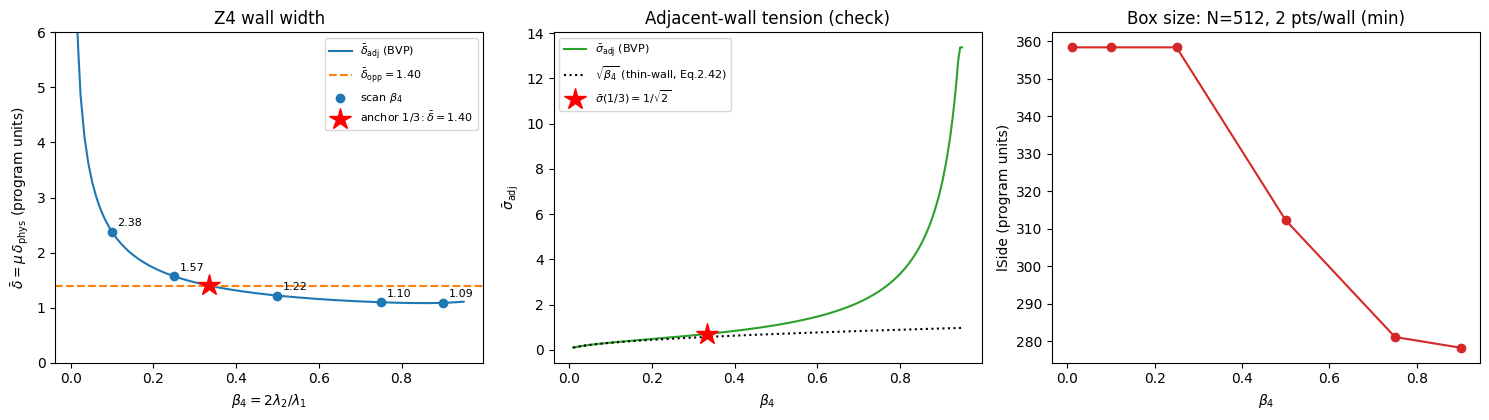

In [4]:
# ---- Verification plot: wall width delta_bar(beta_4) + tension sanity check ----
import matplotlib.pyplot as plt   # default backend (inline in Jupyter, Agg under nbconvert)
bb = np.linspace(0.01, 0.95, 200)
fig, ax = plt.subplots(1, 3, figsize=(15, 4.3))

# (1) wall width: BVP curve, non-adjacent wall, scan points, exact anchor at beta=1/3
ax[0].plot(bb, [delta_adj(b) for b in bb], "-", color="C0", label=r"$\bar\delta_{\rm adj}$ (BVP)")
ax[0].axhline(DELTA_OPP, ls="--", color="C1", label=r"$\bar\delta_{\rm opp}=1.40$")
ax[0].scatter(BETA_VALS, [delta_adj(b) for b in BETA_VALS], color="C0", zorder=5, label="scan $\\beta_4$")
for b in BETA_VALS:
    ax[0].annotate("%.2f" % delta_adj(b), (b, delta_adj(b)), textcoords="offset points", xytext=(4,4), fontsize=8)
ax[0].plot(1/3, delta_adj(1/3), "*", ms=16, color="red", label=r"anchor $1/3\!:\bar\delta{=}1.40$")
ax[0].set_xlabel(r"$\beta_4=2\lambda_2/\lambda_1$"); ax[0].set_ylim(0, 6)
ax[0].set_ylabel(r"$\bar\delta=\mu\,\delta_{\rm phys}$ (program units)")
ax[0].set_title("Z4 wall width"); ax[0].legend(fontsize=8)

# (2) tension sanity check vs analytic limits
ax[1].plot(bb, [sigma_adj(b) for b in bb], "-", color="C2", label=r"$\bar\sigma_{\rm adj}$ (BVP)")
ax[1].plot(bb, np.sqrt(bb), "k:", label=r"$\sqrt{\beta_4}$ (thin-wall, Eq.2.42)")
ax[1].plot(1/3, 1/np.sqrt(2), "*", ms=16, color="red", label=r"$\bar\sigma(1/3)=1/\sqrt{2}$")
ax[1].set_xlabel(r"$\beta_4$"); ax[1].set_ylabel(r"$\bar\sigma_{\rm adj}$")
ax[1].set_title("Adjacent-wall tension (check)"); ax[1].legend(fontsize=8)

# (3) resulting box size from the table
ax[2].plot(df.beta_4, df.lSide, "o-", color="C3")
ax[2].set_xlabel(r"$\beta_4$"); ax[2].set_ylabel("lSide (program units)")
ax[2].set_title("Box size: N=%d, %d pts/wall (%s)" % (N, N_PTS_WIDTH, WALL_TARGET))

fig.tight_layout()
_p = os.path.join(os.getcwd(), "Z4_wallwidth_box_sizing.pdf"); fig.savefig(_p)
print("saved", _p); plt.show()

In [5]:
# ---- Parameter-card creator (mirrors parameter_file_creator_Z4.ipynb) -------
TEMPLATE = """\
#Output
outputfile = {results_dir}

#Evolution
expansion = true
evolver = LF

#Lattice
N = {N}
dt = {dt}
lSide = {lSide:.4f}     # = N * delta_bar({beta:.3f})/{npts}  -> dx = {dx:.4f} ({npts} pts/wall, PRS-fixed)

#Times
t0 = 0
tOutputFreq  = 0.1
tOutputInfreq  = 5
tOutputRareFreq = 3
tMax = {tmax:.1f}      # keeps >= {alpha} Hubble radii/dim ({patches_vol:.0f} patches in volume) at tMax

#Spectra options
PS_type = 1
PS_version = 1

#GWs
GWprojectorType = 2
withGWs = false

fixedBackground = true
omegaEoS = 0.3333
H0 = {H0:.8f}   # {H0_ratio:.4f} * mu

#IC
kCutOff = {kcut}
initial_amplitudes = 0 0
initial_momenta    = 0 0

# Model Parameters  (Z4 domain-wall model)
# V = -mu^2 |Phi|^2 + lambda1 |Phi|^4 - lambda2 (Phi^4 + Phi*^4);  v = 1, beta_4 = {beta:.4f}
mu      = {mu}
lambda1 = {lambda1:.10f}
lambda2 = {lambda2:.10f}

# PRS fat-wall + friction (program units; keeps the comoving wall width fixed).
# delta_bar_adj = {d_adj:.3f}, delta_bar_opp = 1.40, sized on '{wall_target}' wall.
prsWall       = {prsWall}
prsDamping    = {prsDamping}
frictionGamma = {frictionGamma}
frictionEndA  = {frictionEndA}
"""

try:    _root = os.path.dirname(os.path.abspath(__file__))
except NameError: _root = os.getcwd()
out_dir = os.path.join(_root, "..", "src", "models", "parameter-files", OUT_SUBDIR)
os.makedirs(out_dir, exist_ok=True)

def fstr(x): return ("%g" % x).replace(".", "p")
def h0lbl(r): return "H%smu" % (("%g" % r).replace(".", "p"))

generated = []
for mu in MU_VALS:
    for beta in BETA_VALS:
        l1, l2 = couplings_from_mu_beta4(mu, beta)
        d_adj = delta_adj(beta); d_used = width_used(beta)
        lSide = N*d_used/N_PTS_WIDTH; dx = lSide/N
        tmax_ach = lSide/ALPHA_PATCH - 1.0/H0_RATIO
        tmax = tmax_ach if TARGET_TMAX == "auto" else float(TARGET_TMAX)
        a_end = 1.0 + H0_RATIO*tmax; patches_vol = (lSide/(a_end/H0_RATIO))**3
        H0 = H0_RATIO*mu
        for kcut in KCUTOFFS:
            fname = "DWZ4_mu%s_beta4%s_%s_k%d_prs.in" % (fstr(mu), fstr(beta), h0lbl(H0_RATIO), kcut)
            res_dir = "%s/results_z4_mu%s_beta4%s_%s_k%d_prs/" % (REMOTE_BASE, fstr(mu), fstr(beta), h0lbl(H0_RATIO), kcut)
            content = TEMPLATE.format(
                results_dir=res_dir, N=N, dt=DT, lSide=lSide, dx=dx, npts=N_PTS_WIDTH,
                tmax=tmax, alpha=ALPHA_PATCH, patches_vol=patches_vol,
                H0=H0, H0_ratio=H0_RATIO, kcut=kcut, mu=mu, beta=beta,
                lambda1=l1, lambda2=l2, d_adj=d_adj, wall_target=WALL_TARGET,
                prsWall=str(PRS_WALL).lower(), prsDamping=PRS_DAMPING,
                frictionGamma=FRICTION_GAMMA, frictionEndA=FRICTION_END_A)
            with open(os.path.join(out_dir, fname), "w") as fh: fh.write(content)
            generated.append(fname)
            print("%-46s lSide=%8.2f  dx=%6.4f  tMax=%6.1f  patches_vol=%5.1f" %
                  (fname, lSide, dx, tmax, patches_vol))
print("\nGenerated %d cards -> %s" % (len(generated), os.path.abspath(out_dir)))

DWZ4_mu0p01_beta40p01_H1mu_k3_prs.in           lSide=  358.40  dx=0.7000  tMax= 118.5  patches_vol= 27.0
DWZ4_mu0p01_beta40p1_H1mu_k3_prs.in            lSide=  358.40  dx=0.7000  tMax= 118.5  patches_vol= 27.0
DWZ4_mu0p01_beta40p25_H1mu_k3_prs.in           lSide=  358.40  dx=0.7000  tMax= 118.5  patches_vol= 27.0
DWZ4_mu0p01_beta40p5_H1mu_k3_prs.in            lSide=  312.24  dx=0.6098  tMax= 103.1  patches_vol= 27.0
DWZ4_mu0p01_beta40p75_H1mu_k3_prs.in           lSide=  281.11  dx=0.5490  tMax=  92.7  patches_vol= 27.0
DWZ4_mu0p01_beta40p9_H1mu_k3_prs.in            lSide=  278.26  dx=0.5435  tMax=  91.8  patches_vol= 27.0

Generated 6 cards -> /mt/home/dpasari/CosmoLattice_Zn/src/models/parameter-files/scan_z4_prs


### Caveats & how to use

* **PRS makes the physical wall width grow ∝ a**, so the wall tension σ and the GW UV
  spectrum from these cards are **not physical** — use them for the **area/scaling 𝒜** and
  IR observables only. Take σ from the static BVP tensions (`σ̄` computed above × μ³/λ₁) and
  run GW spectra with a fixed-width (`prsWall=false`) run.
* `WALL_TARGET="min"` sizes `dx` on the **thinnest** wall present (the diagonal `δ̄=1.40`
  dominates at β₄<1/3; the adjacent wall dominates at β₄>1/3). Use `"adjacent"` to size only
  on the persistent network wall (bigger boxes / more patches at small β₄).
* `TARGET_TMAX="auto"` gives the **largest** tMax keeping `ALPHA_PATCH` Hubble radii per
  dimension. To run a fixed tMax across all β₄, set a number and watch the horizon-limit warning.
* Everything is in **program units** (ω⋆ = μ). `dt/dx` is reported; keep it ≲ 1/√3 (3D CFL);
  with these dx (~0.5–0.7) and dt=0.01 it is tiny.
* Cards are written to `src/models/parameter-files/{OUT_SUBDIR}/`. Point your `runner_*.sh`
  `PARAM_DIR` at that folder.